In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ibrahimshahrukh/amazon-stock-prices-1997-2025-amzn-ohlcv/AAPL_Stock_Price_Dataset.csv


In [2]:
data=pd.read_csv("/kaggle/input/datasets/ibrahimshahrukh/amazon-stock-prices-1997-2025-amzn-ohlcv/AAPL_Stock_Price_Dataset.csv")
data.head()

,Date,Open,High,Low,Close,Volume,Daily_Return,Price_Range,Price_Change
0,1980-12-15,0.093684,0.093684,0.093256,0.093256,175884800,NaN,0.000428,-0.000428
1,1980-12-16,0.086839,0.086839,0.086412,0.086412,105728000,-7.339797,0.000428,-0.000428
2,1980-12-17,0.088550,0.088978,0.088550,0.088550,86441600,2.475132,0.000428,0.000000
3,1980-12-18,0.091118,0.091545,0.091118,0.091118,73449600,2.899260,0.000428,0.000000
4,1980-12-19,0.096678,0.097106,0.096678,0.096678,48630400,6.102835,0.000428,0.000000


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11354 entries, 0 to 11353
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          11354 non-null  object 
 1   Open          11354 non-null  float64
 2   High          11354 non-null  float64
 3   Low           11354 non-null  float64
 4   Close         11354 non-null  float64
 5   Volume        11354 non-null  int64  
 6   Daily_Return  11353 non-null  float64
 7   Price_Range   11354 non-null  float64
 8   Price_Change  11354 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 798.5+ KB


In [4]:
data['Date'] = pd.to_datetime(data['Date'])


In [5]:
data.isnull().sum()

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Daily_Return    1
Price_Range     0
Price_Change    0
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data.describe()

,Date,Open,High,Low,Close,Volume,Daily_Return,Price_Range,Price_Change
count,11354,11354.000000,11354.000000,11354.000000,11354.000000,1.135400e+04,11353.000000,11354.000000,11354.000000
mean,2003-06-13 07:15:16.329047168,27.944977,28.247652,27.661508,27.967625,3.097171e+08,0.109127,0.586144,0.022648
min,1980-12-15 00:00:00,0.038072,0.038072,0.037645,0.037645,0.000000e+00,-51.869203,0.000000,-14.231336
25%,1992-03-06 18:00:00,0.245930,0.252180,0.240499,0.245770,1.062548e+08,-1.242189,0.007498,-0.009336
50%,2003-06-10 12:00:00,0.481131,0.491290,0.470513,0.482590,1.988224e+08,0.000000,0.023431,0.000000
75%,2014-09-17 18:00:00,21.481897,21.733548,21.238240,21.527946,3.901450e+08,1.420750,0.331782,0.012551
max,2025-12-31 00:00:00,286.200012,288.619995,283.299988,286.190002,7.421641e+09,33.228052,28.622127,26.808337
std,NaN,57.766472,58.385872,57.201837,57.823221,3.334170e+08,2.764016,1.400589,0.920067


In [8]:
data = data.sort_values('Date').reset_index(drop=True)

data.set_index('Date', inplace=True)

print("Date range:", data.index.min(), "→", data.index.max())
print("Total trading days:", len(data))
data.head()

Date range: 1980-12-15 00:00:00 → 2025-12-31 00:00:00
Total trading days: 11354


,Open,High,Low,Close,Volume,Daily_Return,Price_Range,Price_Change
Date,,,,,,,,
1980-12-15,0.093684,0.093684,0.093256,0.093256,175884800,NaN,0.000428,-0.000428
1980-12-16,0.086839,0.086839,0.086412,0.086412,105728000,-7.339797,0.000428,-0.000428
1980-12-17,0.088550,0.088978,0.088550,0.088550,86441600,2.475132,0.000428,0.000000
1980-12-18,0.091118,0.091545,0.091118,0.091118,73449600,2.899260,0.000428,0.000000
1980-12-19,0.096678,0.097106,0.096678,0.096678,48630400,6.102835,0.000428,0.000000


In [9]:
data['MA7']  = data['Close'].rolling(window=7).mean()
data['MA30'] = data['Close'].rolling(window=30).mean()
data['MA90'] = data['Close'].rolling(window=90).mean()

In [10]:
data['Volatility'] = data['Close'].rolling(window=30).std()


In [11]:
delta = data['Close'].diff()
gain  = delta.clip(lower=0)
loss  = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
data['RSI'] = 100 - (100 / (1 + rs))

In [12]:
data['BB_mid']   = data['Close'].rolling(20).mean()
data['BB_upper'] = data['BB_mid'] + 2 * data['Close'].rolling(20).std()
data['BB_lower'] = data['BB_mid'] - 2 * data['Close'].rolling(20).std()


In [13]:
data.dropna(inplace=True)

data.to_csv('amzn_features.csv')

print("Done!")
print("Shape after features:", data.shape)
print("Columns:", list(data.columns))

Done!
Shape after features: (11265, 16)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'Price_Range', 'Price_Change', 'MA7', 'MA30', 'MA90', 'Volatility', 'RSI', 'BB_mid', 'BB_upper', 'BB_lower']


In [14]:
print(data.shape)
print(list(data.columns))
data.head(3)

(11265, 16)
['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'Price_Range', 'Price_Change', 'MA7', 'MA30', 'MA90', 'Volatility', 'RSI', 'BB_mid', 'BB_upper', 'BB_lower']


,Open,High,Low,Close,Volume,Daily_Return,Price_Range,Price_Change,MA7,MA30,MA90,Volatility,RSI,BB_mid,BB_upper,BB_lower
Date,,,,,,,,,,,,,,,,
1981-04-23,0.100100,0.100528,0.100100,0.100100,58016000,2.631392,0.000428,0.000000,0.093073,0.088722,0.095419,0.005755,64.196178,0.090540,0.100351,0.080729
1981-04-24,0.100100,0.100100,0.099245,0.099245,35056000,-0.854624,0.000856,-0.000856,0.093623,0.089463,0.095485,0.005625,62.193987,0.091117,0.101563,0.080672
1981-04-27,0.098817,0.098817,0.098389,0.098389,38528000,-0.862021,0.000428,-0.000428,0.094723,0.090205,0.095619,0.005263,63.750134,0.091802,0.102271,0.081333


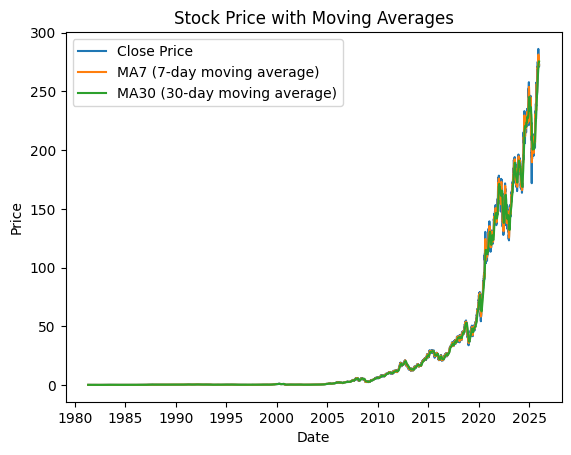

In [15]:
import matplotlib.pyplot as plt

plt.plot(data.index, data['Close'], label='Close Price')
plt.plot(data.index, data['MA7'], label='MA7 (7-day moving average)')
plt.plot(data.index, data['MA30'], label='MA30 (30-day moving average)')

plt.title('Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()


plt.show()

In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_close = scaler.fit_transform(data[['Close']])

print(scaled_close)

[[2.18260858e-04]
 [2.15271251e-04]
 [2.12281539e-04]
 ...
 [9.56561628e-01]
 [9.54185190e-01]
 [9.49921723e-01]]


In [17]:
import numpy as np

def create_sequences(data, window_size=60):
    X, y = [], []
    
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i])
    
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_close, 60)

In [18]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test  = X[split:]

y_train = y[:split]
y_test  = y[split:]

In [19]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8964, 60, 1)
X_test shape: (2241, 60, 1)
y_train shape: (8964, 1)
y_test shape: (2241, 1)


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(units=50))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

# Show architecture
model.summary()

2026-05-03 15:55:36.844551: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777823737.126764      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777823737.204121      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777823737.868089      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777823737.868146      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777823737.868150      57 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - loss: 7.8928e-05 - val_loss: 7.7589e-04
Epoch 2/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - loss: 9.9892e-06 - val_loss: 6.3508e-04
Epoch 3/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - loss: 8.5093e-06 - val_loss: 3.6101e-04
Epoch 4/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - loss: 1.1802e-05 - val_loss: 6.6773e-04
Epoch 5/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - loss: 8.1285e-06 - val_loss: 5.9933e-04
Epoch 6/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - loss: 7.7010e-06 - val_loss: 0.0044
Epoch 7/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - loss: 7.8694e-06 - val_loss: 0.0011
Epoch 8/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - loss: 8.4113e-06 - val_loss: 0.0027
Epoch 9/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - loss: 8.7734e-06 - val_loss: 4.2565e-04
Epoch 10/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - loss: 7.3241e-06 - val_loss: 0.0012
Epoch 11/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step 

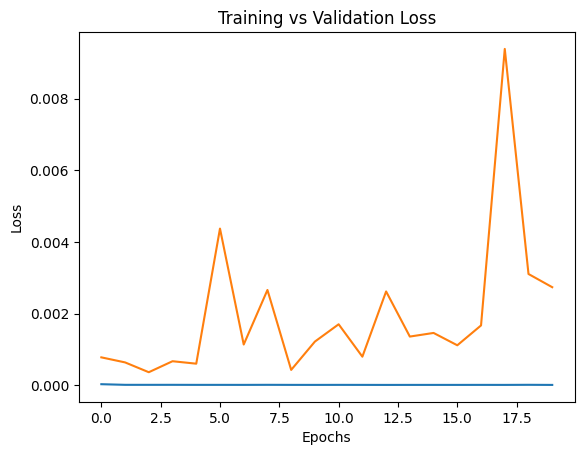

In [22]:
plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.show()

In [23]:
y_pred=model.predict(X_test)

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


In [24]:
y_pred = y_pred.reshape(-1, 1)
y_test=y_test.reshape(-1, 1)

In [25]:
y_pred_real = scaler.inverse_transform(y_pred)
y_test_real = scaler.inverse_transform(y_test)

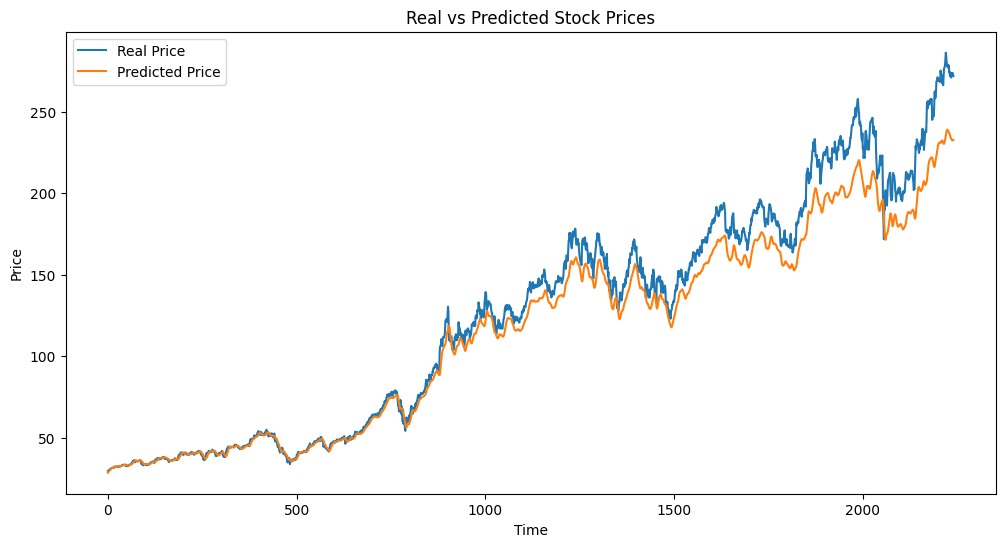

In [26]:
plt.figure(figsize=(12, 6))

plt.plot(y_test_real, label='Real Price')

plt.plot(y_pred_real, label='Predicted Price')

plt.title('Real vs Predicted Stock Prices')
plt.xlabel('Time')
plt.ylabel('Price')

plt.legend()

plt.show()

In [27]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

mae = mean_absolute_error(y_test_real, y_pred_real)

mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)

RMSE: 14.962790903306256
MAE: 10.466346355167579
MAPE: 6.247370377902994


In [29]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(data[['Close']])

print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
print('Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value}')


ADF Statistic: 3.7766652129493936
p-value: 1.0
Critical Values:
   1%: -3.4309326989792823
   5%: -2.8617975213818747
   10%: -2.5669070735184847


In [30]:
from statsmodels.tsa.stattools import adfuller

data['Close_diff'] = data['Close'].diff()

data_diff = data['Close_diff'].dropna()

result = adfuller(data_diff)

print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
print('Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value}')

ADF Statistic: -16.97992995065868
p-value: 9.028116561122959e-30
Critical Values:
   1%: -3.430932802843193
   5%: -2.8617975672795932
   10%: -2.566907097949709


In [32]:
from statsmodels.tsa.arima.model import ARIMA

data.index = pd.to_datetime(data.index)

data = data.asfreq('D')

model = ARIMA(data['Close'], order=(2, 1, 1))

model_fit = model.fit()

forecast = model_fit.forecast(steps=5)

print(forecast)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


2026-01-01    271.962777
2026-01-02    271.962290
2026-01-03    271.961998
2026-01-04    271.962012
2026-01-05    271.962012
Freq: D, Name: predicted_mean, dtype: float64


In [33]:
forecast_result = model_fit.get_forecast(steps=30)

forecast = forecast_result.predicted_mean

conf_int = forecast_result.conf_int()

summary_df = forecast_result.summary_frame()

print(summary_df.head())

Close             mean   mean_se  mean_ci_lower  mean_ci_upper
2026-01-01  271.962777  1.030880     269.942290     273.983265
2026-01-02  271.962290  1.400228     269.217893     274.706686
2026-01-03  271.961998  1.690879     268.647937     275.276060
2026-01-04  271.962012  1.938546     268.162532     275.761492
2026-01-05  271.962012  2.157969     267.732471     276.191553


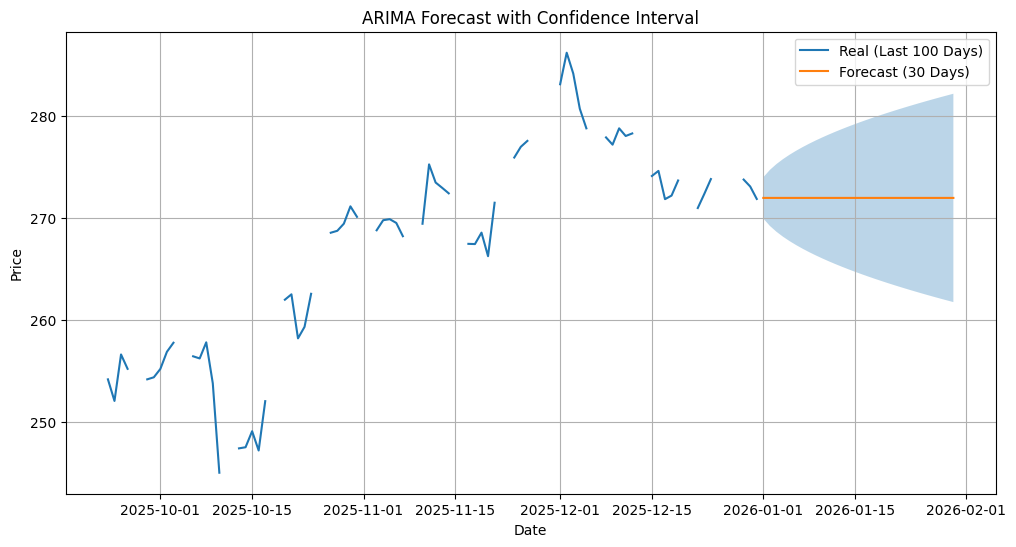

In [34]:
import matplotlib.pyplot as plt

last_100 = data['Close'].tail(100)

forecast_result = model_fit.get_forecast(steps=30)

forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

plt.figure(figsize=(12, 6))

plt.plot(last_100.index, last_100, label='Real (Last 100 Days)')

plt.plot(forecast.index, forecast, label='Forecast (30 Days)')

plt.fill_between(
    forecast.index,
    conf_int.iloc[:, 0],   
    conf_int.iloc[:, 1],   
    alpha=0.3
)

# Labels
plt.title('ARIMA Forecast with Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()
plt.grid()

plt.show()

In [37]:
pred = model_fit.predict(start=0, end=len(data['Close'])-1)

y_true = data['Close']
y_pred = pred

In [39]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

df_eval = data[['Close']].copy()
df_eval['pred'] = pred

df_eval = df_eval.dropna()

y_true = df_eval['Close']
y_pred = df_eval['pred']

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)

RMSE: 1.120791942854941
MAE: 0.35803283379617784
MAPE: 1.9022609426817612


In [41]:
import plotly.graph_objects as go

last_100 = data['Close'].tail(100)

forecast_result = model_fit.get_forecast(steps=30)
forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=last_100.index,
    y=last_100,
    mode='lines',
    name='Real (Last 100 Days)'
))

fig.add_trace(go.Scatter(
    x=forecast.index,
    y=forecast,
    mode='lines',
    name='Forecast (30 Days)'
))

fig.add_trace(go.Scatter(
    x=forecast.index,
    y=conf_int.iloc[:, 1],
    mode='lines',
    line=dict(width=0),
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=forecast.index,
    y=conf_int.iloc[:, 0],
    mode='lines',
    fill='tonexty',
    name='Confidence Interval',
    line=dict(width=0)
))

fig.update_layout(
    title='ARIMA Forecast (Interactive)',
    xaxis_title='Date',
    yaxis_title='Price',
    hovermode='x unified'
)

fig.show()